In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN
from bss.BSMBSS import BSMBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -1, max_val = 1)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  2517257
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 30.003066073850555


(array([0.33447289, 0.33434167, 0.33420622, 0.33255885, 0.33278578]),
 array([2.6164243 , 1.16122176, 0.83104808, 2.01490323, 0.56163273,
        1.14976216, 3.18072101, 2.68273826, 3.82082134, 1.09448324]))

# Hyperparameters

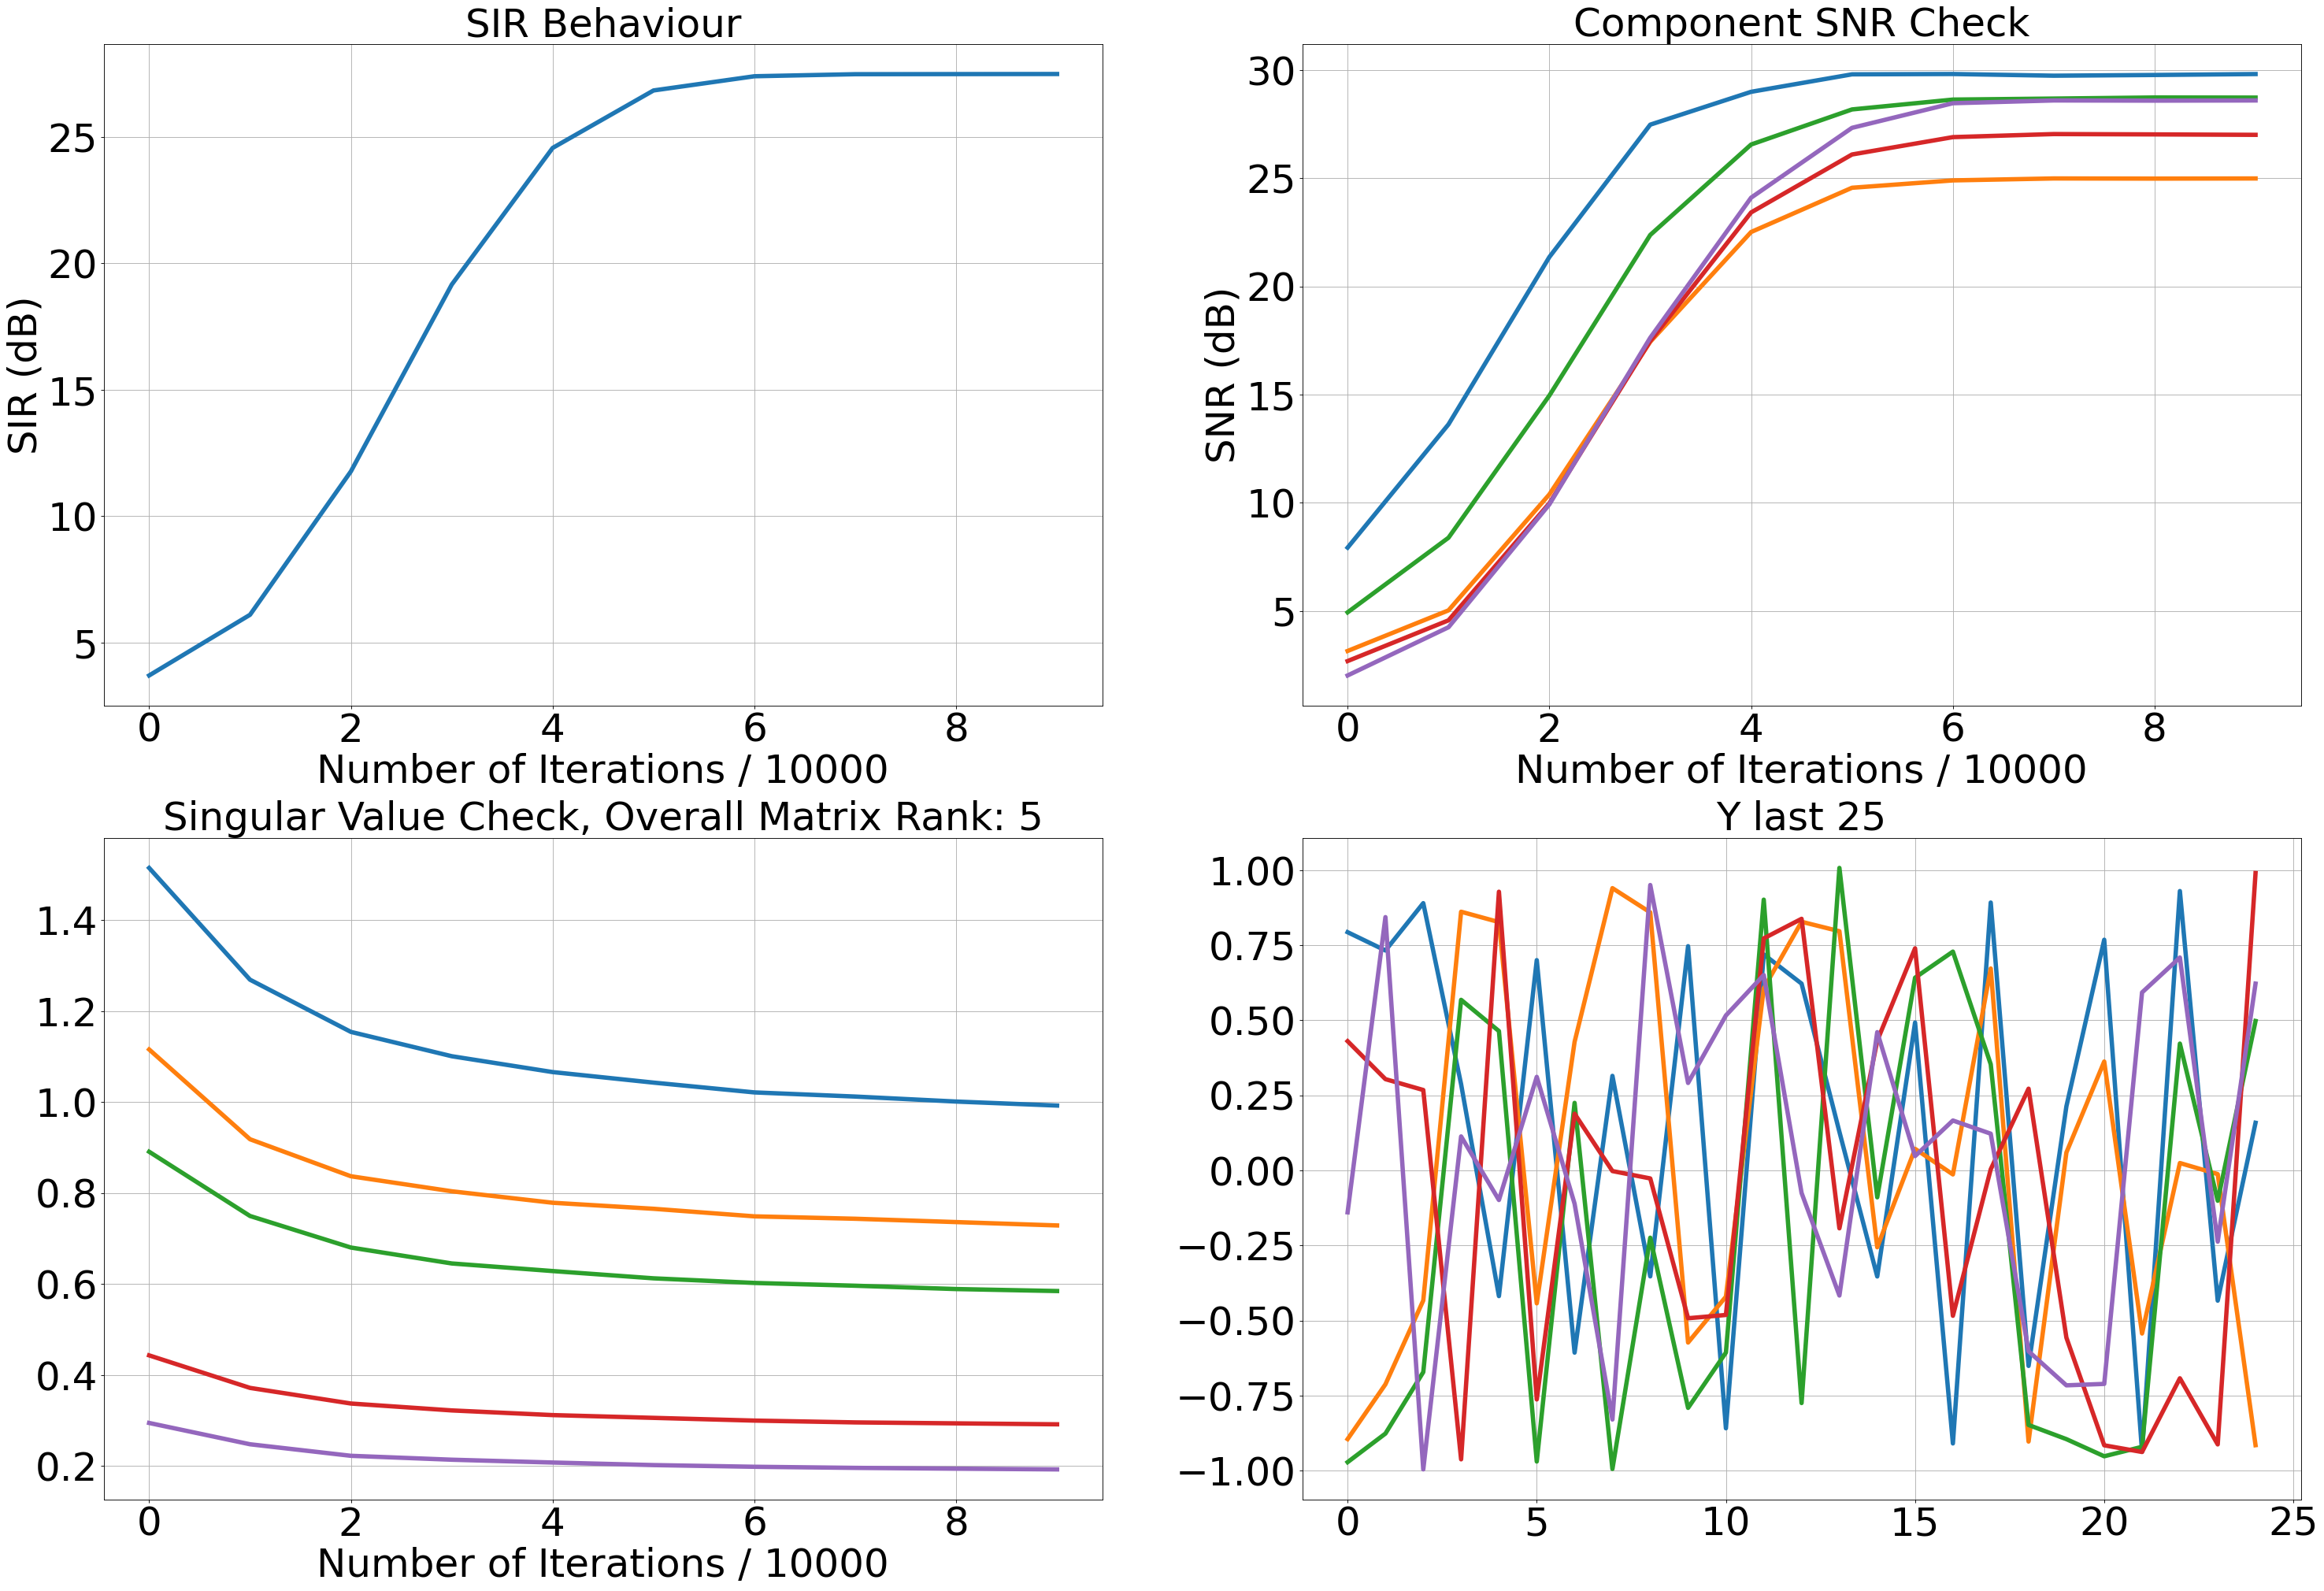

100%|██████████| 100000/100000 [00:22<00:00, 4365.42it/s]


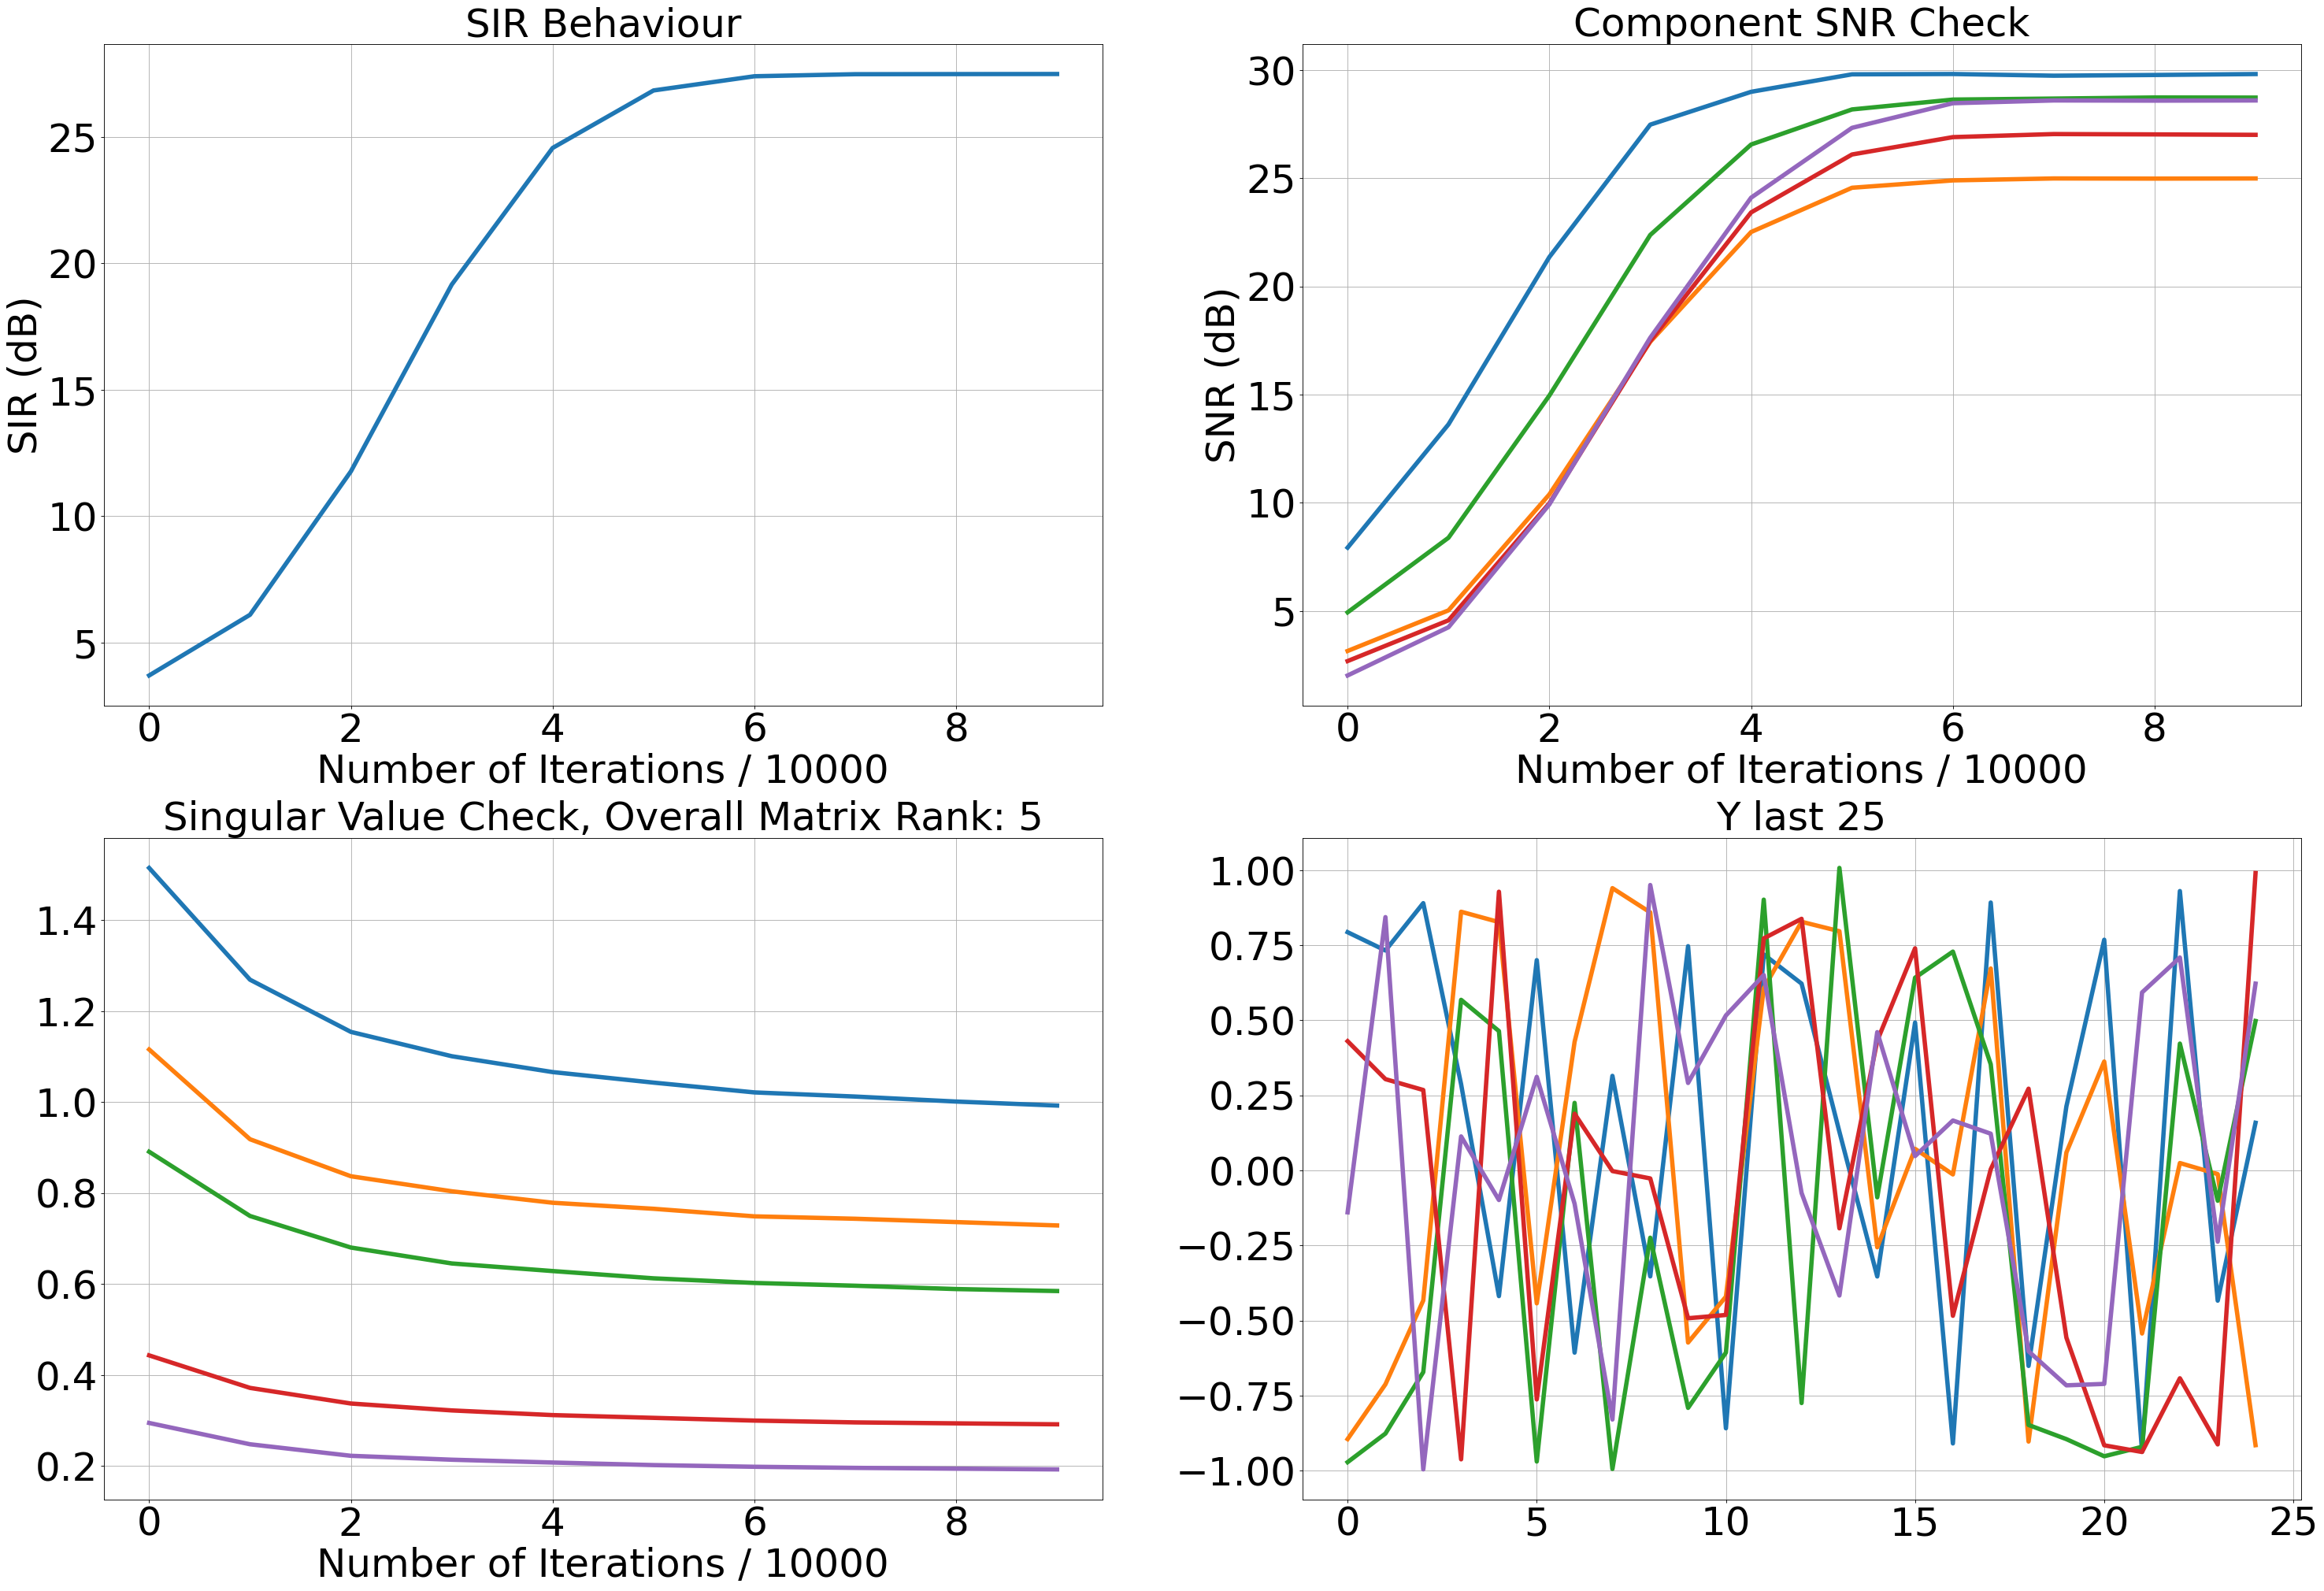

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "antisparse",
                ### Optimization parameters
                "gamma" : 0.9997,
                "eta" : 1e-3,
                "beta" : 1e-6,
                ### Learning rates 
                "neural_lr_start" : 0.005,
                "neural_lr_stop" : 1e-7,
                "neural_dynamics_iterations" : 10,
                "neural_OUTPUT_COMP_TOL" : 1e-7,
                ### Learning rate rules and decay parameters
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "M" : None,
                "D" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = BSMBSS(**hyperparam_dict)
model.fit(X)

In [4]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.D.reshape(1, -1))

<IPython.core.display.Math object>

In [6]:
display_matrix(model.M)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 27.50173578422014
Component Signal-to-Noise-Ratio (SNR) Values : [29.86665393 24.97443588 28.76164006 27.05553116 28.66677103]



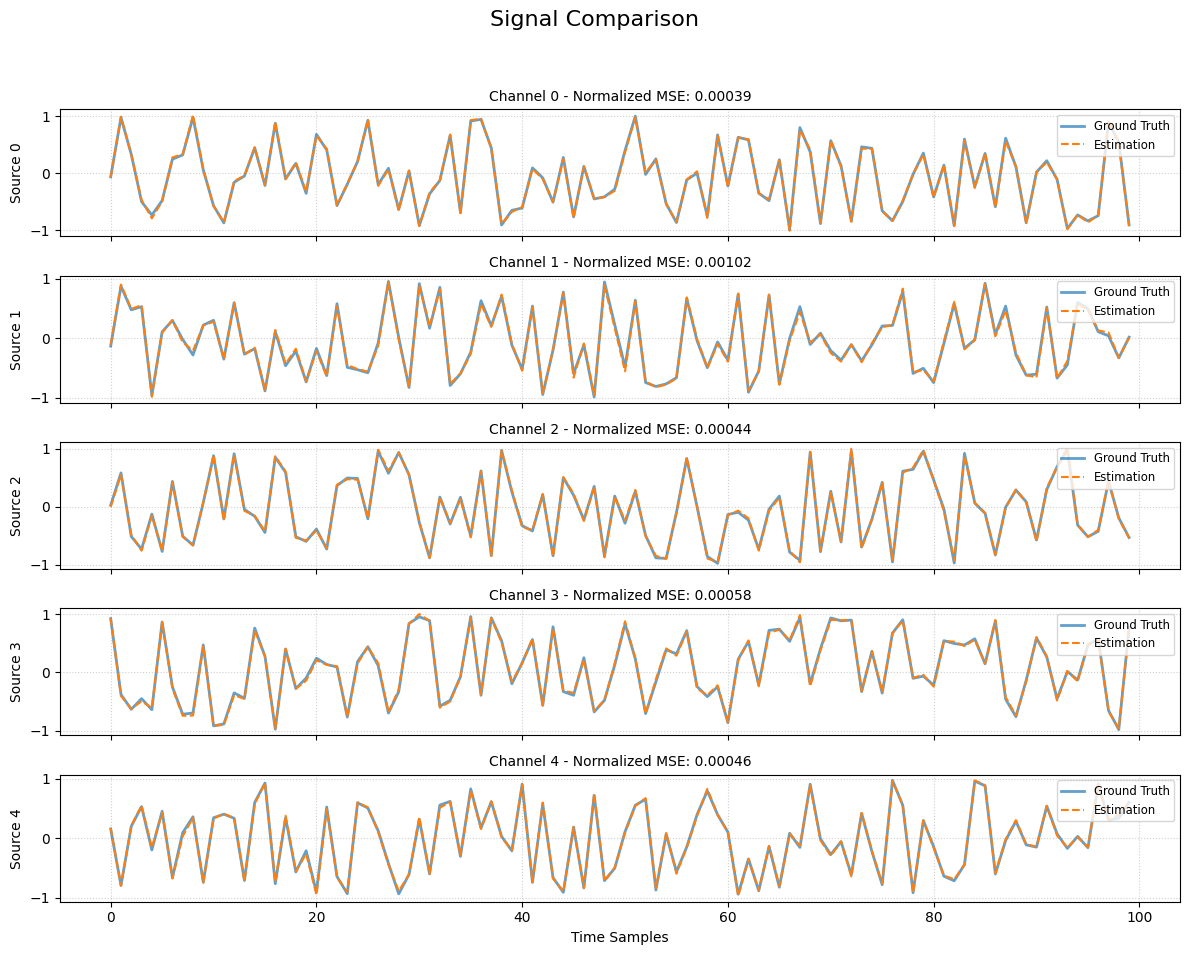

In [8]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])